# Определение возраста покупателей

Сетевой супермаркет внедряет систему компьютерного зрения для обработки фотографий покупателей. Фотофиксация в прикассовой зоне поможет определять возраст клиентов, чтобы:

- Анализировать покупки и предлагать товары, которые могут заинтересовать покупателей этой возрастной группы;
- Контролировать добросовестность кассиров при продаже алкоголя.

Необходимо построить модель, которая по фотографии определит приблизительный возраст человека. В нашем распоряжении набор фотографий людей с указанием возраста.

**Описание данных**

Данные взяты с сайта [ChaLearn Looking at People](http://chalearnlap.cvc.uab.es/dataset/26/description/). Они находятся в папке `/datasets/faces/`.

В нашем распоряжении одна папка со всеми изображениями (`/final_files`) и CSV-файл `labels.csv` с двумя колонками: `file_name` и `real_age`.

## Исследовательский анализ данных

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator

<div class="alert alert-success">
<h2> Комментарий ревьюера v1 <a class="tocSkip"> </h2>

<b>Все супер!👍:</b>  Всегда собираем и структурируем пипы, импорты и константы в начале тетрадки, это позволяет легче ориентироваться и добавлять новые по необходимости! А все основные моменты, касающиеся РЕР8, всегда можно освежить в памяти [здесь](https://pyplanet.ru/article/pep-0008.html)
    

### Загрузка данных

In [2]:
labels = pd.read_csv('/datasets/faces/labels.csv')

In [3]:
display(labels.head())
labels.info()

,file_name,real_age
0,000000.jpg,4
1,000001.jpg,18
2,000002.jpg,80
3,000003.jpg,50
4,000004.jpg,17


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7591 entries, 0 to 7590
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   file_name  7591 non-null   object
 1   real_age   7591 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 118.7+ KB


### EDA

In [4]:
datagen = ImageDataGenerator(rescale=1./255)
data_flow = datagen.flow_from_dataframe(
    labels,
    '/datasets/faces/final_files/',
    x_col='file_name',
    y_col='real_age',
    target_size=(150, 150),
    batch_size=16,
    class_mode='raw',
    seed=42)

Found 7591 validated image filenames.


Выборка содержит 7591 изображение

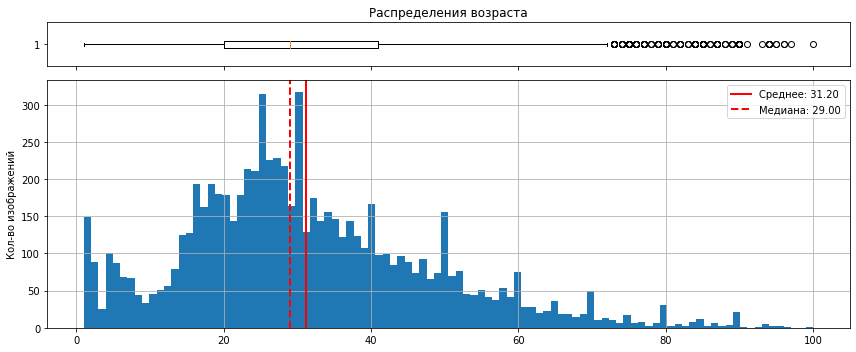

count    7591.000000
mean       31.201159
std        17.145060
min         1.000000
25%        20.000000
50%        29.000000
75%        41.000000
max       100.000000
Name: real_age, dtype: float64


In [5]:
fig, axes = plt.subplots(ncols=1, nrows=2, gridspec_kw={'height_ratios' : [15, 85]}, figsize=(12, 5), sharex=True)
axes[0].boxplot(labels['real_age'], vert=False)
axes[0].set_title('Распределения возраста')

axes[1].hist(labels['real_age'], bins=100)
axes[1].set_ylabel('Кол-во изображений')
axes[1].axvline(labels['real_age'].mean(), color='red', linestyle='-', linewidth=2, label=f'Среднее: {labels["real_age"].mean():.2f}')
axes[1].axvline(labels['real_age'].median(), color='red', linestyle='--', linewidth=2, label=f'Медиана: {labels["real_age"].median():.2f}')

plt.tight_layout()
plt.legend()
plt.grid()
plt.show()
print(labels['real_age'].describe().T)

В целом значение возраста распределено равномерно. Больше всего людей возраста около 25 лет.

In [6]:
x, y = next(data_flow)

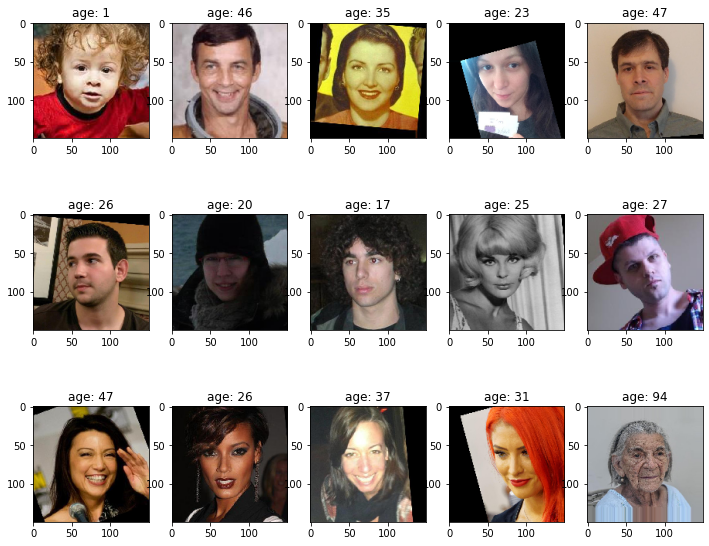

In [7]:
fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(12,10))
for i in range(15):
    axes[i // 5, i % 5].imshow(x[i])
    axes[i // 5, i % 5].set_title(f'age: {y[i]}')

На изображениях видны люди расположенные по центру картинки.

### Вывод

- В датасете 7591 изображений
- Значения возраста распределено равномерно, однако видны большие пики в 25 и 30 лет, что может говорить о приблизительной оценке возраста
- Изображения в датасете - цветные, на некоторых изображениях лица повёрнуты чтобы располагаться вертикально и по центру, но не везде (например, мужчина 27 лет в красной кепке расположен не вертикально).

## Обучение модели

Код обучения модели (ResNet50) (запускался на отдельном сервере с GPU)

```python

import pandas as pd
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D 
from tensorflow.keras.models import Sequential
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet import ResNet50
from tensorflow.keras.optimizers import Adam

def load_train(path):
    labels = pd.read_csv('/datasets/faces/labels.csv')
    datagen_train = ImageDataGenerator(validation_split=0.25, rescale=1./255, horizontal_flip=True)
    train_datagen_flow = datagen_train.flow_from_dataframe(
        labels,
        path + '/final_files/',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='training',
        seed=42
    )
    
    return train_datagen_flow

def load_test(path):
    labels = pd.read_csv('/datasets/faces/labels.csv')
    datagen_test = ImageDataGenerator(validation_split=0.25, rescale=1./255)
    test_datagen_flow = datagen_test.flow_from_dataframe(
        labels,
        path + '/final_files',
        x_col='file_name',
        y_col='real_age',
        target_size=(224, 224),
        batch_size=32,
        class_mode='raw',
        subset='validation',
        seed=42
    )
    return test_datagen_flow
    
def create_model(input_shape):
    backbone = ResNet50(
        input_shape=input_shape,
        weights='/datasets/keras_models/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5',
        include_top=False)

    model = Sequential()
    model.add(backbone)
    model.add(GlobalAveragePooling2D())
    model.add(Dense(1, activation='relu'))
    
    model.compile(optimizer=Adam(0.0001), loss='mse', metrics=['mae'])

    return model


def train_model(model, train_data, test_data, batch_size=None, epochs=10,
               steps_per_epoch=None, validation_steps=None):
    model.fit(train_data, 
              validation_data=test_data,
              batch_size=batch_size, 
              epochs=epochs,
              steps_per_epoch=steps_per_epoch,
              validation_steps=validation_steps,
              verbose=2,
              shuffle=True)

    return model

```

**Результат обучения модели**

```
Train for 178 steps, validate for 60 steps
Epoch 1/10
178/178 - 60s - loss: 223.9249 - mae: 10.6958 - val_loss: 929.5698 - val_mae: 25.5661
Epoch 2/10
178/178 - 38s - loss: 75.6611 - mae: 6.5501 - val_loss: 467.2810 - val_mae: 16.1927
Epoch 3/10
178/178 - 38s - loss: 49.8211 - mae: 5.3624 - val_loss: 328.8767 - val_mae: 13.4095
Epoch 4/10
178/178 - 38s - loss: 35.9968 - mae: 4.5742 - val_loss: 144.4613 - val_mae: 9.1071
Epoch 5/10
178/178 - 38s - loss: 27.5151 - mae: 4.0049 - val_loss: 84.3389 - val_mae: 6.9753
Epoch 6/10
178/178 - 38s - loss: 22.6189 - mae: 3.6175 - val_loss: 69.6016 - val_mae: 6.1814
Epoch 7/10
178/178 - 38s - loss: 18.2646 - mae: 3.2701 - val_loss: 66.4048 - val_mae: 6.0061
Epoch 8/10
178/178 - 38s - loss: 14.8390 - mae: 2.9525 - val_loss: 68.0592 - val_mae: 6.0399
Epoch 9/10
178/178 - 38s - loss: 12.4577 - mae: 2.6881 - val_loss: 65.5413 - val_mae: 6.0712
Epoch 10/10
178/178 - 38s - loss: 10.9146 - mae: 2.5324 - val_loss: 63.1688 - val_mae: 5.9900
```

## Анализ обученной модели

На основе полученных данных была проделана следующая работа:

**Анализ данных**

- В датасете 7591 изображений
- Значения возраста распределено равномерно, однако видны большие пики в 25 и 30 лет, что может говорить о приблизительной оценке возраста
- Изображения в датасете - цветные, на некоторых изображениях лица повёрнуты чтобы располагаться вертикально и по центру, но не везде (например, мужчина 27 лет в красной кепке расположен не вертикально).

**Обучение модели**

Значение метрики MAE на тестовой выборке 5.99

В среднем модель ошибается на 6 лет, что для покупателей старшего возраста не критично, но у более молодых покупателей 18-25 лет разница в 6 лет может значительно изменять интересы по покупкам.

Также ошибка в 6 лет делает модель не особо пригодной для контроля продажи алкоголя, так как она может оценить 12-летнего как 18-летнего.

**Итог**

Хотя критерий "MAE меньше 8 на тестовой выборке" выполнен, среднее значение ошибки в 6 лет делает модель не до конца пригодной для выполнения обеих поставленных задач.